In [1]:
pip install numpy==1.26.4 pandas==2.2.2 scikit-learn==1.4.2 scipy==1.13.0 matplotlib==3.8.4 seaborn==0.13.2 GEOparse==2.0.4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
"""
Step 1: Download and preprocess the GSE45827 breast cancer gene expression dataset.
Splits into 3 balanced batches with a simulated batch effect.
"""

import GEOparse
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os

DATASET_ID = "GSE45827"
DATA_DIR   = "data"
os.makedirs(DATA_DIR, exist_ok=True)


def download_and_preprocess():
    print(f"Downloading {DATASET_ID} from GEO (this may take a minute)...")
    gse = GEOparse.get_GEO(geo=DATASET_ID, destdir=DATA_DIR, silent=True)

    print("Extracting expression matrix and labels...")
    expr_frames = []
    sample_ids  = []
    labels      = {}

    for gsm_name, gsm in gse.gsms.items():
        if gsm.table is None or gsm.table.empty:
            continue

        col = gsm.table.set_index("ID_REF")["VALUE"]
        expr_frames.append(col)
        sample_ids.append(gsm_name)

        # GSE45827 stores subtype in characteristics_ch1
        # e.g. "tissue: luminal A" or "subtype: HER2+" etc.
        label = "unknown"
        for ch in gsm.metadata.get("characteristics_ch1", []):
            ch_lower = ch.lower()
            if any(kw in ch_lower for kw in ["luminal", "her2", "basal", "normal", "tnbc"]):
                label = ch.split(":")[-1].strip()
                break
            if "tissue" in ch_lower or "subtype" in ch_lower or "type" in ch_lower:
                label = ch.split(":")[-1].strip()
        labels[gsm_name] = label

    expr_df = pd.concat(expr_frames, axis=1)
    expr_df.columns = sample_ids
    expr_df = expr_df.dropna()

    print(f"Raw matrix: {expr_df.shape[0]} probes x {expr_df.shape[1]} samples")

    # Top 300 most variable genes
    top_genes = expr_df.var(axis=1).nlargest(300).index
    expr_df   = expr_df.loc[top_genes]

    # Z-score normalise
    scaler      = StandardScaler()
    expr_scaled = pd.DataFrame(
        scaler.fit_transform(expr_df.T).T,
        index=expr_df.index, columns=expr_df.columns
    )

    label_series = pd.Series(labels, name="subtype").reindex(sample_ids)
    print("Label distribution:", label_series.value_counts().to_dict())

    # Balanced 3-batch split (interleaved so each batch has all subtypes)
    n     = expr_scaled.shape[1]
    idx   = np.arange(n)
    rng   = np.random.default_rng(42)

    splits = [idx[0::3], idx[1::3], idx[2::3]]
    for b_num, b_idx in enumerate(splits, start=1):
        bdf   = expr_scaled.iloc[:, b_idx].copy()
        # Simulated batch effect: additive column-wise shift
        shift = rng.normal(loc=b_num * 0.4, scale=0.05, size=(bdf.shape[0], 1))
        bdf   = bdf + shift
        bdf.to_csv(os.path.join(DATA_DIR, f"batch_{b_num}.csv"))
        print(f"  batch_{b_num}: {bdf.shape[1]} samples")

    label_series.to_csv(os.path.join(DATA_DIR, "true_labels.csv"), header=True)
    print(f"\nAll files saved to '{DATA_DIR}/'")


if __name__ == "__main__":
    download_and_preprocess()

D:\c programming\proj\.venv\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


Extracting expression matrix and labels...
Raw matrix: 29873 probes x 155 samples
Label distribution: {'Basal': 41, 'Her2': 30, 'Luminal B': 30, 'Luminal A': 29, 'unknown': 14, 'None (normal)': 11}
  batch_1: 52 samples
  batch_2: 52 samples
  batch_3: 51 samples

All files saved to 'data/'


<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
C:\Users\yasha\AppData\Local\Temp\ipykernel_8132\3331606203.py:29: SyntaxWarning: invalid escape sequence '\c'
  DATA_DIR   = "D:\c programming\proj\datasets"
C:\Users\yasha\AppData\Local\Temp\ipykernel_8132\3331606203.py:33: SyntaxWarning: invalid escape sequence '\c'
  PLOTS_DIR  = "D:\c programming\proj\datasets\plots"


Loaded batch_1: (51, 500)
Loaded batch_2: (51, 500)
Loaded batch_3: (53, 500)

Total samples: 155, Features: 500
Classes: ['184B5' 'BT-549' 'BT20' 'Breast cancer' 'HCC1143' 'HCC1187' 'HCC1937'
 'HCC38' 'HCC70' 'Hs 578T' 'MCF-12A' 'MDA-MB-157' 'MDA-MB-231'
 'MDA-MB-436' 'MDA-MB-468' 'None (normal)']

--- Per-batch K-means clustering ---


C:\Users\yasha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\yasha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\yasha\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yasha\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\yasha\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

  batch_1: clusters found = [0 1 2 3 4 5]
  batch_2: clusters found = [0 1 2 3 4 5]


D:\c programming\proj\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\c programming\proj\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

  batch_1: clusters found = [0 1 2 3 4 5]
  batch_2: clusters found = [0 1 2 3 4 5]


D:\c programming\proj\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\c programming\proj\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  batch_3: clusters found = [0 1 2 3 4 5]

--- ADMM Consensus (50 iterations, rho=1.0) ---
  Converged at iteration 1


D:\c programming\proj\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\c programming\proj\.venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



--- Baseline: K-means on full data ---

  Baseline K-means (all data)
  ARI  (↑ better, max 1): 0.1511
  NMI  (↑ better, max 1): 0.4428
  Silhouette (↑ better) : 0.1760

  ADMM Consensus Clustering
  ARI  (↑ better, max 1): 0.2170
  NMI  (↑ better, max 1): 0.4683
  Silhouette (↑ better) : 0.1350
Consensus matrix plot saved → D:\c programming\proj\datasets\plots\consensus_matrix.png


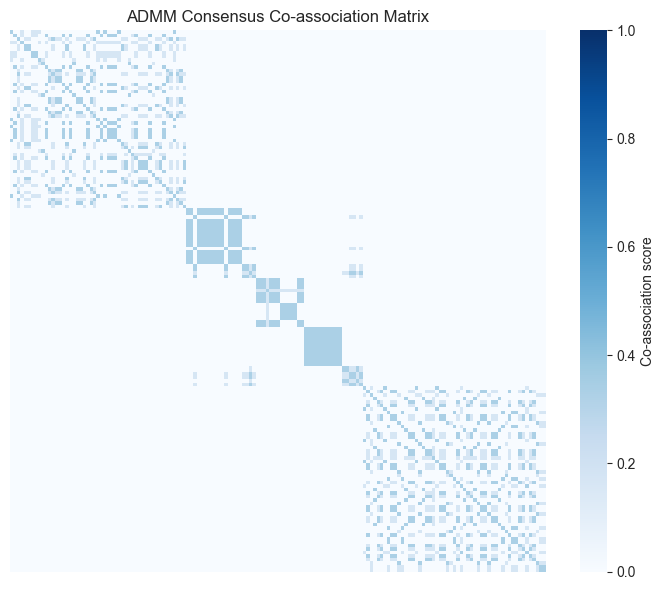

ADMM convergence plot saved → D:\c programming\proj\datasets\plots\admm_convergence.png


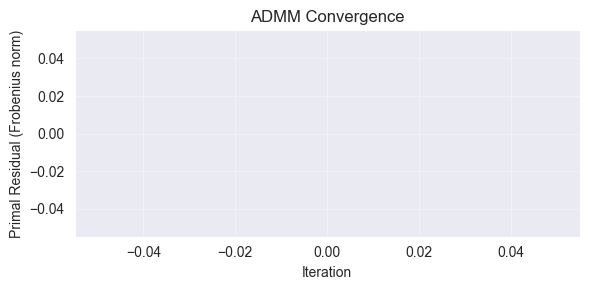


PCA plot saved → D:\c programming\proj\datasets\plots\pca_clusters.png


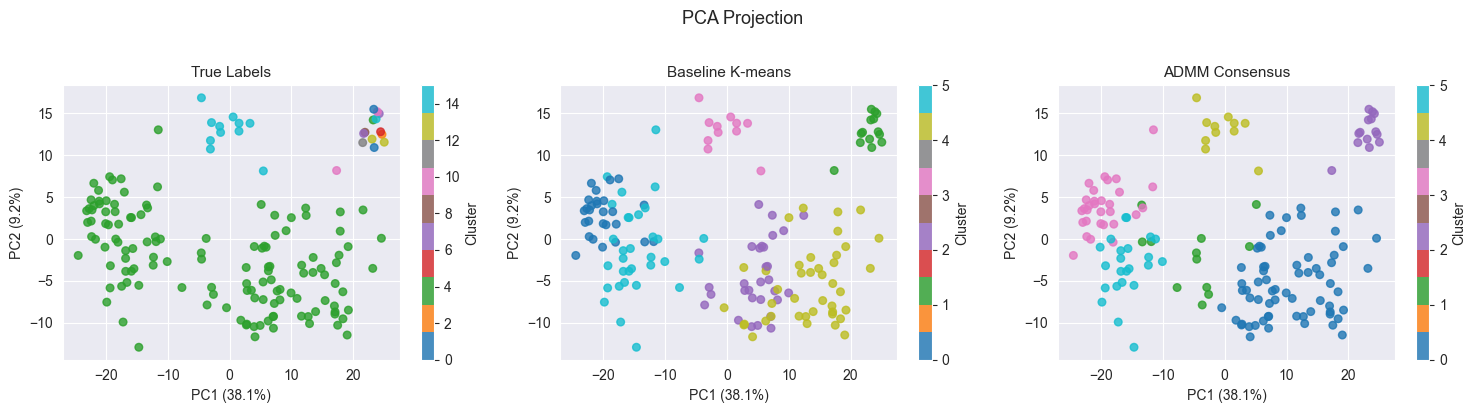

Metrics comparison plot saved → D:\c programming\proj\datasets\plots\metrics_comparison.png


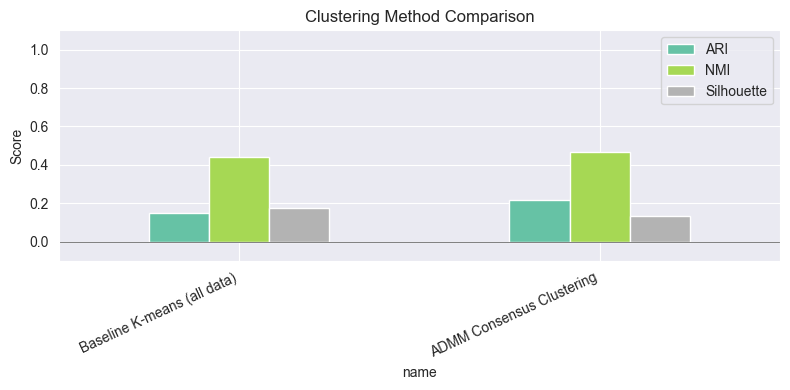


Done! All plots saved to the 'plots/' folder.


In [3]:
"""
Step 2: Distributed Consensus Clustering using K-means, Spectral Clustering, and ADMM.

Pipeline:
  1. Load each batch CSV produced by step1_download_data.py
  2. Run K-means AND spectral clustering on each batch separately
  3. Convert each cluster assignment to a co-association (similarity) matrix
  4. Solve the consensus problem using ADMM over all batches
  5. Evaluate and visualize results
"""

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from scipy.spatial.distance import squareform, pdist

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_DIR   = "D:\c programming\proj\datasets"
N_CLUSTERS = 6        # GSE45827 has 6 breast cancer subtypes
N_ITER     = 50       # ADMM iterations
RHO        = 1.0      # ADMM penalty parameter
PLOTS_DIR  = "D:\c programming\proj\datasets\plots"
os.makedirs(PLOTS_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
def load_batches():
    batches = {}
    for fname in sorted(os.listdir(DATA_DIR)):
        if fname.startswith("batch_") and fname.endswith(".csv"):
            key = fname.replace(".csv", "")
            df = pd.read_csv(os.path.join(DATA_DIR, fname), index_col=0)
            batches[key] = df.T.values   # shape: (n_samples, n_genes)
            print(f"Loaded {key}: {batches[key].shape}")

    labels_df = pd.read_csv(os.path.join(DATA_DIR, "true_labels.csv"), index_col=0)
    true_labels_raw = labels_df.iloc[:, 0].values
    le = LabelEncoder()
    true_labels = le.fit_transform(true_labels_raw)
    return batches, true_labels, le.classes_


# ─────────────────────────────────────────────
# 2. CLUSTERING PER BATCH
# ─────────────────────────────────────────────
def run_kmeans(X, k=N_CLUSTERS):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    return km.fit_predict(X)


def run_spectral(X, k=N_CLUSTERS):
    # Build RBF similarity graph
    sc = SpectralClustering(
        n_clusters=k,
        affinity="rbf",
        gamma=0.01,
        random_state=42,
        n_init=10
    )
    return sc.fit_predict(X)


# ─────────────────────────────────────────────
# 3. CO-ASSOCIATION MATRIX
# ─────────────────────────────────────────────
def co_association_matrix(labels):
    """
    Build an n x n binary matrix C where C[i,j]=1 if i and j are in the same cluster.
    This is the 'soft' representation of a clustering used in consensus.
    """
    n = len(labels)
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                C[i, j] = 1.0
    return C


# ─────────────────────────────────────────────
# 4. ADMM CONSENSUS
# ─────────────────────────────────────────────
def admm_consensus(co_matrices, n_clusters=N_CLUSTERS, n_iter=N_ITER, rho=RHO):
    """
    Consensus clustering via ADMM.

    Problem:
        minimise   sum_b  || Z - C_b ||_F^2
        subject to Z is a valid (rounded) co-association matrix

    ADMM formulation (simplified primal consensus):
        x-update:  Z = average of (C_b + dual_b / rho)   [closed-form]
        z-update:  project Z onto the set of co-association matrices
                   (round to nearest 0/1 by thresholding at 0.5)
        dual update: dual_b += rho * (Z - C_b)

    Here we work with the continuous relaxation and do the final hard
    assignment once ADMM converges.
    """
    n = co_matrices[0].shape[0]
    B = len(co_matrices)

    # Initialise
    Z = np.mean(co_matrices, axis=0)          # consensus matrix (continuous)
    duals = [np.zeros((n, n)) for _ in range(B)]

    residuals = []

    for it in range(n_iter):
        # ── x-update: average of augmented co-assoc matrices ──
        Z_new = np.zeros((n, n))
        for b in range(B):
            Z_new += co_matrices[b] + duals[b] / rho
        Z_new /= B

        # ── z-update: project onto [0,1] (box constraint relaxation) ──
        Z_new = np.clip(Z_new, 0.0, 1.0)
        # Enforce symmetry
        Z_new = (Z_new + Z_new.T) / 2.0

        # ── dual update ──
        for b in range(B):
            duals[b] += rho * (Z_new - co_matrices[b])

        # ── primal residual ──
        primal_res = np.linalg.norm(Z_new - Z, "fro")
        residuals.append(primal_res)
        Z = Z_new

        if (it + 1) % 10 == 0:
            print(f"  ADMM iter {it+1:3d}/{n_iter}  |  primal residual = {primal_res:.6f}")

        if primal_res < 1e-5:
            print(f"  Converged at iteration {it+1}")
            break

    return Z, residuals


def extract_clusters_from_consensus(Z, n_clusters=N_CLUSTERS):
    """
    Convert consensus matrix to cluster labels via spectral clustering.
    Treat Z as an affinity matrix.
    """
    sc = SpectralClustering(
        n_clusters=n_clusters,
        affinity="precomputed",
        random_state=42,
        n_init=10
    )
    labels = sc.fit_predict(Z)
    return labels


# ─────────────────────────────────────────────
# 5. EVALUATION
# ─────────────────────────────────────────────
def evaluate(name, pred_labels, true_labels, X_all):
    ari  = adjusted_rand_score(true_labels, pred_labels)
    nmi  = normalized_mutual_info_score(true_labels, pred_labels)
    try:
        sil = silhouette_score(X_all, pred_labels)
    except Exception:
        sil = float("nan")
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  ARI  (↑ better, max 1): {ari:.4f}")
    print(f"  NMI  (↑ better, max 1): {nmi:.4f}")
    print(f"  Silhouette (↑ better) : {sil:.4f}")
    return {"name": name, "ARI": ari, "NMI": nmi, "Silhouette": sil}


# ─────────────────────────────────────────────
# 6. PLOTS
# ─────────────────────────────────────────────
def plot_pca(X_all, labels_dict, title_suffix=""):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_all)
    var  = pca.explained_variance_ratio_

    n_plots = len(labels_dict)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for ax, (name, labels) in zip(axes, labels_dict.items()):
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                             c=labels, cmap="tab10", s=30, alpha=0.8)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
        ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
        plt.colorbar(scatter, ax=ax, label="Cluster")

    plt.suptitle(f"PCA Projection {title_suffix}", fontsize=13, y=1.02)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "pca_clusters.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"\nPCA plot saved → {path}")
    plt.show()


def plot_consensus_matrix(Z, title="Consensus Co-association Matrix"):
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(Z, cmap="Blues", ax=ax, xticklabels=False, yticklabels=False,
                vmin=0, vmax=1, cbar_kws={"label": "Co-association score"})
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "consensus_matrix.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Consensus matrix plot saved → {path}")
    plt.show()


def plot_admm_residuals(residuals):
    plt.figure(figsize=(6, 3))
    plt.plot(residuals, color="steelblue", linewidth=1.5)
    plt.xlabel("Iteration")
    plt.ylabel("Primal Residual (Frobenius norm)")
    plt.title("ADMM Convergence")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "admm_convergence.png")
    plt.savefig(path, dpi=150)
    print(f"ADMM convergence plot saved → {path}")
    plt.show()


def plot_metrics(results):
    df = pd.DataFrame(results).set_index("name")
    df[["ARI", "NMI", "Silhouette"]].plot(
        kind="bar", figsize=(8, 4), colormap="Set2", edgecolor="white"
    )
    plt.title("Clustering Method Comparison")
    plt.ylabel("Score")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(-0.1, 1.1)
    plt.axhline(0, color="gray", linewidth=0.7)
    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, "metrics_comparison.png")
    plt.savefig(path, dpi=150)
    print(f"Metrics comparison plot saved → {path}")
    plt.show()


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def main():
    # 1. Load data
    batches, true_labels, class_names = load_batches()
    batch_names = list(batches.keys())

    # Stack all samples for evaluation and PCA
    X_all = np.vstack(list(batches.values()))

    # Align true labels to stacked order
    # (true_labels loaded in sample order matching concat of batches)

    print(f"\nTotal samples: {X_all.shape[0]}, Features: {X_all.shape[1]}")
    print(f"Classes: {class_names}")

    # 2. Per-batch clustering + co-association matrices
    print("\n--- Per-batch K-means clustering ---")
    km_labels_list = []
    km_co_matrices = []
    for bname in batch_names:
        X_b = batches[bname]
        lbl = run_kmeans(X_b)
        km_labels_list.append(lbl)
        km_co_matrices.append(co_association_matrix(lbl))
        print(f"  {bname}: clusters found = {np.unique(lbl)}")

    print("\n--- Per-batch Spectral clustering ---")
    sc_labels_list = []
    sc_co_matrices = []
    for bname in batch_names:
        X_b = batches[bname]
        lbl = run_spectral(X_b)
        sc_labels_list.append(lbl)
        sc_co_matrices.append(co_association_matrix(lbl))
        print(f"  {bname}: clusters found = {np.unique(lbl)}")

    # Combine both methods' co-association matrices for ADMM
    all_co_matrices = km_co_matrices + sc_co_matrices
    # Each co-matrix covers its own batch's samples; for global consensus
    # we create block-diagonal co-association matrices padded with zeros
    n_total = X_all.shape[0]
    batch_sizes = [batches[b].shape[0] for b in batch_names]
    offsets = np.cumsum([0] + batch_sizes)

    def pad_coassoc(C, batch_idx, n_total, offsets):
        """Embed a local co-assoc matrix into the global n_total x n_total space."""
        C_global = np.zeros((n_total, n_total))
        s, e = offsets[batch_idx], offsets[batch_idx + 1]
        C_global[s:e, s:e] = C
        return C_global

    all_co_global = []
    for b_idx in range(len(batch_names)):
        all_co_global.append(pad_coassoc(km_co_matrices[b_idx], b_idx, n_total, offsets))
        all_co_global.append(pad_coassoc(sc_co_matrices[b_idx], b_idx, n_total, offsets))

    # 3. ADMM consensus
    print(f"\n--- ADMM Consensus ({N_ITER} iterations, rho={RHO}) ---")
    Z_consensus, residuals = admm_consensus(all_co_global, n_clusters=N_CLUSTERS,
                                             n_iter=N_ITER, rho=RHO)

    # 4. Extract final labels from consensus matrix
    consensus_labels = extract_clusters_from_consensus(Z_consensus, N_CLUSTERS)

    # 5. Baseline: naive K-means on all data (no consensus)
    print("\n--- Baseline: K-means on full data ---")
    baseline_labels = run_kmeans(X_all)

    # 6. Evaluate
    results = []
    results.append(evaluate("Baseline K-means (all data)", baseline_labels, true_labels, X_all))
    results.append(evaluate("ADMM Consensus Clustering", consensus_labels, true_labels, X_all))

    # 7. Plots
    plot_consensus_matrix(Z_consensus, "ADMM Consensus Co-association Matrix")
    plot_admm_residuals(residuals)
    plot_pca(X_all, {
        "True Labels":            true_labels,
        "Baseline K-means":       baseline_labels,
        "ADMM Consensus":         consensus_labels,
    })
    plot_metrics(results)

    print("\nDone! All plots saved to the 'plots/' folder.")


if __name__ == "__main__":
    main()